### EOF on multiple layers

In [1]:
#!/usr/bin/env python3
# ============================================================
# Combined EOF Analysis for depth-mean CMIP6 ocean temperature and salinity
# for the ATLANTIC (using already-masked files)
#
# For each model, this script:
#   - loads all thetao_masked_*.nc members
#   - computes depth-mean thetao for:
#         0–300 m, 0–1000 m, 1000–5000 m
#   - computes combined EOFs across members
#   - saves EOF, PC(member,time,mode), variance_fraction
#
# Works for:
#   EC-Earth3 (75 levels)
#   IPSL-CM6A-LR (75 levels)
#   CESM2 (60 levels)
#   MPI-ESM1-2-LR (40 levels)
# ============================================================

import os
import glob
import re
import numpy as np
import xarray as xr
from eofs.standard import Eof
import warnings
warnings.filterwarnings("ignore")

# ============================
# CONFIG (EDIT HERE)
# ============================
MODEL   = "CESM2"   # ← CHANGE: EC-Earth3, IPSL-CM6A-LR, CESM2, MPI-ESM1-2-LR
VAR     = "so"
NMODES  = 10            # we only need the first 10 modes

# Input dirs (already Atlantic-masked θ)
if MODEL == "EC-Earth3":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{VAR}/regridded/"
elif MODEL == "IPSL-CM6A-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/{VAR}/masked/"
elif MODEL == "CESM2":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/CESM2/{VAR}/masked/"
elif MODEL == "MPI-ESM1-2-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/MPI-ESM1-2-LR/{VAR}/masked/"
else:
    raise ValueError("Unknown MODEL")

OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/"
os.makedirs(OUT_DIR, exist_ok=True)

START_YEAR = 1850
END_YEAR   = 2014

# depth ranges (in meters)
DEPTH_RANGES = [
    (0.0, 300.0),
    (0.0, 1000.0),
    (1000.0, 5000.0),
]

# ============================
# 1. UNIVERSAL GRID STANDARDIZATION
# ============================

def standardize_latlon(ds):
    """
    Standardize lat/lon to 2D arrays with dims ('y','x') for ALL grid types:
    - Regular grid:   lat(lat), lon(lon)   → broadcast to 2D
    - Curvilinear:    lat(j,i), lon(j,i)   → rename dims to ('y','x')
    Removes EC-Earth3 bogus coordinate variables named 'x'/'y'.
    """

    # detect lat/lon var names
    lat_var = next((v for v in ["lat", "latitude", "nav_lat"] if v in ds), None)
    lon_var = next((v for v in ["lon", "longitude", "nav_lon"] if v in ds), None)
    if lat_var is None or lon_var is None:
        raise KeyError("latitude/longitude not found")

    lat = ds[lat_var]
    lon = ds[lon_var]

    # ---------------------------------------------
    # CASE A — Regular grid (1D lat, 1D lon)
    # ---------------------------------------------
    if lat.ndim == 1 and lon.ndim == 1:
        print("   → Regular grid (1D lat/lon) detected")

        # broadcast into 2D
        lon2d, lat2d = np.meshgrid(lon.values, lat.values)

        # remove old lat/lon
        ds2 = ds.drop_vars([lat_var, lon_var])

        # rename dims first (safe)
        ds2 = ds2.rename_dims({lat.dims[0]: "y", lon.dims[0]: "x"})

        # add new 2D coords
        ds2["lat"] = xr.DataArray(lat2d, dims=("y", "x"))
        ds2["lon"] = xr.DataArray(lon2d, dims=("y", "x"))

        return ds2, ("y", "x")

    # ---------------------------------------------
    # CASE B — Curvilinear grid (2D lat, 2D lon)
    # ---------------------------------------------
    elif lat.ndim == 2 and lon.ndim == 2:
        print("   → Curvilinear grid (2D lat/lon) detected")

        ydim, xdim = lat.dims   # e.g. ("j","i")

        # swap_dims allows renaming even if ds has variables named 'x'/'y'
        ds2 = ds.swap_dims({ydim: "y", xdim: "x"})

        # rename lat/lon variables
        ds2 = ds2.rename({lat_var: "lat", lon_var: "lon"})

        # drop EC-Earth3 bogus vars
        for bad in ["x", "y"]:
            if bad in ds2 and bad not in ["lat", "lon"]:
                print(f"   ⚠ Dropping variable '{bad}' (conflicts with dims)")
                try:
                    ds2 = ds2.drop_vars(bad)
                except Exception:
                    pass

        return ds2, ("y", "x")

    else:
        raise ValueError("Unknown lat/lon grid format")

# ============================
# 2. MEMBER LABEL EXTRACTION
# ============================

def parse_member_label(path):
    base = os.path.basename(path)
    m = re.search(r"_(r\d+i\d+p\d+f\d+)", base)
    if m:
        return m.group(1)
    return os.path.splitext(base)[0]

# ============================
# 3. FIND VERTICAL DIMENSION
# ============================

def get_depth_dim_and_coord(da, ds):
    """
    Detect vertical dimension and return:
        depth_dim_name, depth_coord_in_meters
    Handles:
        - EC-Earth3  (olevel in meters)
        - IPSL       (olevel in meters)
        - CESM2      (lev in centimeters → convert to meters)
    """

    # Case A — EC-Earth3 / IPSL use "olevel"
    if "olevel" in da.dims:
        return "olevel", ds["olevel"]

    # Case B — some models use "depth"
    if "depth" in da.dims:
        return "depth", ds["depth"]

    # Case C — CESM2 (POP2) uses "lev" with z_t in centimeters
    if "lev" in da.dims:
        lev = ds["lev"].values

        # Detect if values are in centimeters (typical POP2)
        # CESM2 vertical grid values: 500, 1500, ..., 530000 cm
        if lev.max() > 10000:  # > 100 m → definitely cm
            depth_m = lev / 100.0
            depth_da = xr.DataArray(depth_m, dims=("lev",), name="depth")
            return "lev", depth_da

        # If lev already in meters (unusual), fallback:
        depth_da = xr.DataArray(lev, dims=("lev",), name="depth")
        return "lev", depth_da

    raise KeyError("No recognized vertical coordinate found (olevel/lev/depth)")


# ============================
# 4. PROCESS: ONE DEPTH RANGE
# ============================

def run_depth_range(zmin, zmax):
    print(f"\n==============================")
    print(f"Depth range: {zmin:.0f}–{zmax:.0f} m")
    print(f"==============================\n")

    # -----------------------------------------------------------------
    # 4.1. Load all members and compute depth-mean anomalies per member
    # -----------------------------------------------------------------
    pattern = os.path.join(IN_DIR, f"{VAR}_Oyear_{MODEL}_historical_r*i1p1f1_*_masked.nc")
    files = sorted(glob.glob(pattern))
    if not files:
        # fallback: maybe just r* pattern
        pattern = os.path.join(IN_DIR, f"{VAR}_masked_r*.nc")
        files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No masked {VAR} files for {MODEL} in {IN_DIR}")

    print(f"📂 Found {len(files)} members for {MODEL}\n")

    anom_list = []
    member_labels = []
    lat2d = lon2d = None

    for idx, f in enumerate(files, start=1):
        label = parse_member_label(f)
        member_labels.append(label)

        print(f"→ Loading member {idx}/{len(files)}: {os.path.basename(f)} ({label})")
        ds = xr.open_dataset(f)

        # Standardize grid
        print("   Standardizing spatial dims…")
        ds, (yd, xd) = standardize_latlon(ds)
        if lat2d is None:
            lat2d = ds["lat"]
            lon2d = ds["lon"]

        da = ds[VAR]  # thetao

        # detect vertical dim
        depth_dim, depth_coord = get_depth_dim_and_coord(da, ds)

        # Subset time
        yrs = da["time"].dt.year
        start = START_YEAR if START_YEAR else int(yrs.min())
        end   = END_YEAR   if END_YEAR   else int(yrs.max())
        da = da.sel(time=slice(f"{start}-01-01", f"{end}-12-31"))

        # -----------------------------------------
        # Select depth levels in [zmin, zmax] m
        # -----------------------------------------
        depth_vals = depth_coord.values
        mask_depth = (depth_vals >= zmin) & (depth_vals <= zmax)

        if mask_depth.sum() == 0:
            raise ValueError(
                f"No depth levels found in {zmin}–{zmax} m for file {f}"
            )

        print(f"   Using {mask_depth.sum()} levels in this range")

        da_sel = da.isel({depth_dim: mask_depth})

        # depth-mean temperature (simple mean over chosen levels)
        da_meanz = da_sel.mean(dim=depth_dim)

        # compute anomaly (remove time mean)
        print("   Computing anomaly…")
        anom = da_meanz - da_meanz.mean("time")

        # add member dimension
        anom = anom.expand_dims(member=[label])
        anom_list.append(anom)

    # -----------------------------------------
    # 4.2. Align time across members
    # -----------------------------------------
    print("\n🧭 Finding common time axis…")

    common_time = anom_list[0]["time"].values
    for a in anom_list[1:]:
        common_time = np.intersect1d(common_time, a["time"].values)

    if common_time.size == 0:
        raise ValueError("No overlapping time range across members!")

    common_time = xr.DataArray(common_time, dims=("time",))
    print(f"   → Common timesteps: {common_time.size}\n")

    aligned = [a.sel(time=common_time) for a in anom_list]
    combined = xr.concat(aligned, dim="member")

    n_member = combined.sizes["member"]
    n_time   = combined.sizes["time"]
    ny, nx   = combined.sizes["y"], combined.sizes["x"]

    print(f"   → Combined shape: member={n_member}, time={n_time}, y={ny}, x={nx}")

    # -----------------------------------------
    # 4.3. Prepare data for EOF
    # -----------------------------------------
    print("\n🧱 Preparing for EOF solver…")
    # combined has dims (member, time, y, x)
    data = combined.transpose("member", "time", "y", "x").values
    data2d = data.reshape(n_member * n_time, ny * nx)
    data2d = np.ma.masked_invalid(data2d)

    # compute spatial weights (area or cos(lat))
    print("→ Computing weights…")
    ref_ds = xr.open_dataset(files[0])
    if "areacello" in ref_ds:
        area = ref_ds["areacello"]
        if area.ndim == 2:
            w = np.sqrt(area.values.reshape(ny * nx))
        else:
            w = np.sqrt(np.cos(np.deg2rad(lat2d.values)).reshape(ny * nx))
    else:
        w = np.sqrt(np.cos(np.deg2rad(lat2d.values)).reshape(ny * nx))

    # -----------------------------------------
    # 4.4. Run EOF
    # -----------------------------------------
    print("\n🚀 Running EOF solver…")
    solver = Eof(data2d, weights=w)

    EOFs = solver.eofs(neofs=NMODES).reshape(NMODES, ny, nx)
    PCs_flat = solver.pcs(npcs=NMODES)  # shape (n_member*n_time, NMODES)
    VF   = solver.varianceFraction()[0:NMODES]

    # reshape PCs back to (member, time, mode)
    PCs = PCs_flat.reshape(n_member, n_time, NMODES)

    # -----------------------------------------
    # 4.5. Save output
    # -----------------------------------------
    zlabel = f"{int(zmin)}-{int(zmax)}m"
    outfile = os.path.join(
        OUT_DIR,
        f"EOF_combined_{VAR}_depthmean_{zlabel}.nc"
    )

    print(f"\n💾 Saving output to:\n   {outfile}")

    ds_out = xr.Dataset(
        {
            "EOF": (("mode", "y", "x"), EOFs),
            "PC":  (("member", "time", "mode"), PCs),
            "variance_fraction": (("mode",), VF),
        },
        coords={
            "mode": np.arange(1, NMODES + 1),
            "member": np.array(member_labels, dtype=object),
            "time": common_time,
            "lat": lat2d,
            "lon": lon2d,
        },
    )

    ds_out.to_netcdf(outfile)
    print("\n🎉 DONE for this depth range.\n")


# ============================
# 5. RUN FOR ALL DEPTH RANGES
# ============================

if __name__ == "__main__":
    print(f"=== MODEL: {MODEL}, variable: {VAR} ===")
    for (zmin, zmax) in DEPTH_RANGES:
        run_depth_range(zmin, zmax)
    print("\n✅ All depth ranges processed for this model.\n")



=== MODEL: CESM2, variable: so ===

Depth range: 0–300 m

📂 Found 11 members for CESM2

→ Loading member 1/11: so_masked_r10i1p1f1.nc (r10i1p1f1)
   Standardizing spatial dims…
   → Curvilinear grid (2D lat/lon) detected
   Using 26 levels in this range
   Computing anomaly…
→ Loading member 2/11: so_masked_r11i1p1f1.nc (r11i1p1f1)
   Standardizing spatial dims…
   → Curvilinear grid (2D lat/lon) detected
   Using 26 levels in this range
   Computing anomaly…
→ Loading member 3/11: so_masked_r1i1p1f1.nc (r1i1p1f1)
   Standardizing spatial dims…
   → Curvilinear grid (2D lat/lon) detected
   Using 26 levels in this range
   Computing anomaly…
→ Loading member 4/11: so_masked_r2i1p1f1.nc (r2i1p1f1)
   Standardizing spatial dims…
   → Curvilinear grid (2D lat/lon) detected
   Using 26 levels in this range
   Computing anomaly…
→ Loading member 5/11: so_masked_r3i1p1f1.nc (r3i1p1f1)
   Standardizing spatial dims…
   → Curvilinear grid (2D lat/lon) detected
   Using 26 levels in this range


In [8]:
import xarray as xr

ds = xr.open_dataset("/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r10i1p1f1.nc")
print(ds)


<xarray.Dataset> Size: 5GB
Dimensions:  (time: 165, nlat: 384, nlon: 320, lev: 60)
Coordinates:
  * time     (time) object 1kB 1850-06-30 06:00:00 ... 2014-06-30 06:00:00
    lon      (nlat, nlon) float64 983kB ...
    lat      (nlat, nlon) float64 983kB ...
  * nlon     (nlon) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
  * nlat     (nlat) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * lev      (lev) float64 480B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
Data variables:
    thetao   (time, lev, nlat, nlon) float32 5GB ...


## Plotting script

In [2]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ============================================
# SETTINGS
# ============================================
MODEL = "CESM2"   # EC-Earth3, IPSL-CM6A-LR, CESM2, MPI-ESM1-2-LR
VAR   = "so"

EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/"
OUT_DIR = f"/data/users/frekle/EOF/{MODEL}/Figures/{VAR}/Depths"
os.makedirs(OUT_DIR, exist_ok=True)

DEPTH_LABELS = [
    "0-300m",
    "0-1000m",
    "1000-5000m"
]

NMODES = 10


# ============================================================
#  Helper: symmetric color range
# ============================================================
def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax


# ============================================================
# Helper: Native-grid scatter-method EOF plotting
# ============================================================
def plot_eof_native(ax, lat, lon, eof_field, title):
    # wrap lon to [-180, 180]
    lon2 = ((lon + 180) % 360) - 180

    vmin, vmax = symmetric_clim(eof_field)

    sc = ax.scatter(
        lon2.values, lat.values,
        c=eof_field.values,
        s=4,                     # bigger, more visible
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

    ax.set_xlim(-180, 180)
    ax.set_ylim(lat.min(), lat.max())

    # control stretching: slightly higher aspect for better map proportions
    ax.set_aspect(1.5)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, label="EOF loading")
    return cbar


# ============================================================
# MAIN LOOP OVER DEPTH RANGES
# ============================================================
for dlabel in DEPTH_LABELS:

    print(f"\n📘 Processing EOFs & PCs for depth range: {dlabel}")

    # -------------------------
    # Make folder for this depth category
    # -------------------------
    depth_dir = os.path.join(OUT_DIR, dlabel)
    os.makedirs(depth_dir, exist_ok=True)

    # -------------------------
    # Load EOF file
    # -------------------------
    fpattern = f"{EOF_DIR}/EOF_combined_{VAR}_depthmean_{dlabel}.nc"
    files = glob.glob(fpattern)
    if not files:
        print(f"❌ File not found: {fpattern}")
        continue

    ds = xr.open_dataset(files[0])

    EOF = ds["EOF"]         # (mode, y, x)
    PC  = ds["PC"]          # (member, time, mode)
    VF  = ds["variance_fraction"].values
    lat = ds["lat"]
    lon = ds["lon"]
    time = ds["time"]

    # ============================================
    # Fix time axis
    # ============================================
    if not np.issubdtype(time.dtype, np.datetime64):
        try:
            time = ds.indexes["time"].to_datetimeindex().values
        except:
            time = ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    else:
        time = time.values

    # How many modes actually exist?
    max_modes = EOF.sizes["mode"]
    used_modes = min(NMODES, max_modes)


    # ============================================
    # One Figure PER MODE (side-by-side layout)
    # ============================================
    for m in range(used_modes):
        var_exp = VF[m] * 100.0
        eof_field = EOF.isel(mode=m)

        fig, axes = plt.subplots(
            1, 2,
            figsize=(14, 5),
            gridspec_kw={'width_ratios': [1.2, 2.2]}
        )

        fig.suptitle(
            f"{VAR} — {MODEL} — {dlabel}\nEOF {m+1} + PC {m+1}",
            fontsize=14
        )

        # -------- LEFT PANEL: EOF SPATIAL --------
        title = f"EOF {m+1} — {var_exp:.1f}% variance"
        plot_eof_native(
            axes[0],
            lat, lon,
            eof_field,
            title
        )

        # -------- RIGHT PANEL: PC TIMESERIES --------
        ax = axes[1]
        pcs_all  = PC.isel(mode=m)        # (member, time)
        pcs_mean = pcs_all.mean("member")
        pcs_std  = pcs_all.std("member")

        for mem in range(pcs_all.sizes["member"]):
            ax.plot(
                time,
                pcs_all.isel(member=mem),
                color="gray",
                alpha=0.25,
                lw=0.6
            )

        ax.plot(time, pcs_mean, color="black", lw=2)

        ax.fill_between(
            time,
            pcs_mean - pcs_std,
            pcs_mean + pcs_std,
            color="red",
            alpha=0.15,
            edgecolor="red",
            linewidth=0.5,
        )

        ax.axhline(0, color="black", lw=0.6)
        ax.grid(alpha=0.3)
        ax.set_title(f"PC {m+1}", fontsize=12)
        ax.set_xlabel("Time")

        fig.tight_layout(rect=[0, 0, 1, 0.93])

        outfile = os.path.join(depth_dir, f"EOF_PC_mode_{m+1:02d}.png")
        fig.savefig(outfile, dpi=150)
        plt.close(fig)

        print(f"💾 Saved mode {m+1}: {outfile}")


    # ============================================
    # PC MATRIX PLOT
    # ============================================
    print("🗂️ Saving PC Matrix")

    fig, ax = plt.subplots(figsize=(14, 6))
    pc_matrix = PC.mean("member").transpose("mode", "time").values

    pcm = ax.pcolormesh(
        time,
        np.arange(pc_matrix.shape[0]),
        pc_matrix,
        cmap="viridis",
        shading="nearest"
    )

    ax.set_title(f"PC Matrix (Time × Mode) — {dlabel}", fontsize=14)
    ax.set_ylabel("Mode number")
    ax.set_xlabel("Time")
    ax.set_yticks(np.arange(pc_matrix.shape[0]))

    plt.colorbar(pcm, ax=ax, label="PC amplitude")

    fig.tight_layout()
    outfile = os.path.join(depth_dir, "PC_matrix.png")
    fig.savefig(outfile, dpi=150)
    plt.close(fig)

    print(f"💾 Saved: {outfile}")



📘 Processing EOFs & PCs for depth range: 0-300m
💾 Saved mode 1: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_01.png
💾 Saved mode 2: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_02.png
💾 Saved mode 3: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_03.png
💾 Saved mode 4: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_04.png
💾 Saved mode 5: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_05.png
💾 Saved mode 6: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_06.png
💾 Saved mode 7: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_07.png
💾 Saved mode 8: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_08.png
💾 Saved mode 9: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_09.png
💾 Saved mode 10: /data/users/frekle/EOF/CESM2/Figures/so/Depths/0-300m/EOF_PC_mode_10.png
🗂️ Saving PC Matrix
💾 Saved: /data/users/frekle/EOF/CESM2/Fi

In [1]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ============================================
# SETTINGS
# ============================================
MODEL = "IPSL-CM6A-LR"   # EC-Earth3, IPSL-CM6A-LR, CESM2, MPI-ESM1-2-LR
VAR   = "thetao"

EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/figures_native/"
os.makedirs(OUT_DIR, exist_ok=True)

DEPTH_LABELS = [
    "0-300m",
    "0-1000m",
    "1000-5000m"
]

NMODES = [0, 1, 2, 3, 4, 6, 7, 9]   # plot EOF/PC modes 1–3


# ============================================================
#  Helper: symmetric color range
# ============================================================
def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax


# ============================================================
# Helper: Native-grid scatter-method EOF plotting
# ============================================================
def plot_eof_native(ax, lat, lon, eof_field, title):
    lon2 = ((lon + 180) % 360) - 180   # wrap to [-180,180]

    vmin, vmax = symmetric_clim(eof_field)

    sc = ax.scatter(
        lon2.values, lat.values,
        c=eof_field.values,
        s=1.0,
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
    )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, shrink=0.6)


# ============================================================
# MAIN LOOP OVER DEPTH RANGES
# ============================================================
for dlabel in DEPTH_LABELS:

    print(f"\n📘 Plotting EOF + PC for depth range {dlabel}")

    # --- load file ---
    fpattern = f"{EOF_DIR}/EOF_combined_{VAR}_depthmean_{dlabel}.nc"
    files = glob.glob(fpattern)
    if not files:
        print(f"❌ File not found: {fpattern}")
        continue

    ds = xr.open_dataset(files[0])

    EOF = ds["EOF"]         # (mode, y, x)
    PC  = ds["PC"]          # (member, time, mode)
    VF  = ds["variance_fraction"].values
    lat = ds["lat"]
    lon = ds["lon"]
    time = ds["time"]

    # ============================================
    # FIX TIME AXIS (cftime → numpy datetime64)
    # ============================================
    if not np.issubdtype(time.dtype, np.datetime64):
        try:
            time = ds.indexes["time"].to_datetimeindex().values
        except:
            time = ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    else:
        time = time.values

    # ============================================
    # FIGURE 1: EOF1–3 + PC1–3
    # ============================================
    fig, axes = plt.subplots(2, NMODES, figsize=(18, 8))
    fig.suptitle(f"{MODEL}: EOFs & PCs — {dlabel}", fontsize=16)

    # ------------------------------
    # 1. EOF Spatial Maps
    # ------------------------------
    for m in range(NMODES):
        var_exp = VF[m] * 100.0
        title = f"EOF {m+1} — {var_exp:.1f}% variance"

        plot_eof_native(
            axes[0, m],
            lat, lon,
            EOF.isel(mode=m),
            title=title
        )

    # ------------------------------
    # 2. PC Timeseries
    # ------------------------------
    for m in range(NMODES):
        ax = axes[1, m]
        pcs_all  = PC.isel(mode=m)        # (member, time)
        pcs_mean = pcs_all.mean("member")
        pcs_std  = pcs_all.std("member")

        # all members (grey lines)
        for mem in range(pcs_all.sizes["member"]):
            ax.plot(
                time,
                pcs_all.isel(member=mem),
                color="gray",
                alpha=0.25,
                lw=0.6
            )

        # mean
        ax.plot(time, pcs_mean, color="black", lw=2)

        # ±std shading
        ax.fill_between(
            time,
            pcs_mean - pcs_std,
            pcs_mean + pcs_std,
            color="red",
            alpha=0.15,
            edgecolor="red",
            linewidth=0.5,
        )

        ax.axhline(0, color="black", lw=0.6)
        ax.grid(alpha=0.3)
        ax.set_title(f"PC {m+1}")
        ax.set_xlabel("Time")

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outfile = f"{OUT_DIR}/{MODEL}_EOF_PC_first3_{dlabel}.png"
    # fig.savefig(outfile, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile}")

    # ============================================
    # FIGURE 2: PC MATRIX (time × mode)
    # ============================================
    fig, ax = plt.subplots(figsize=(14, 6))

    # member-mean over members
    pc_matrix = PC.mean("member").transpose("mode", "time").values  # (mode,time)

    pcm = ax.pcolormesh(
        time,
        np.arange(pc_matrix.shape[0]),
        pc_matrix,
        cmap="viridis",
        shading="nearest"        # ← IMPORTANT FIX
    )

    ax.set_title(f"PC Matrix (Time × Mode) — {dlabel}", fontsize=14)
    ax.set_ylabel("Mode number")
    ax.set_xlabel("Time")
    ax.set_yticks(np.arange(pc_matrix.shape[0]))
    plt.colorbar(pcm, ax=ax, label="PC amplitude")

    fig.tight_layout()
    outfile2 = f"{OUT_DIR}/{MODEL}_PC_matrix_{dlabel}.png"
    # fig.savefig(outfile2, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile2}")



📘 Plotting EOF + PC for depth range 0-300m


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


ValueError: Number of columns must be a positive integer, not [0, 1, 2, 3, 4, 6, 7, 9]

<Figure size 1800x800 with 0 Axes>

### Salinity plots


📘 Plotting EOF + PC for depth range 0-300m


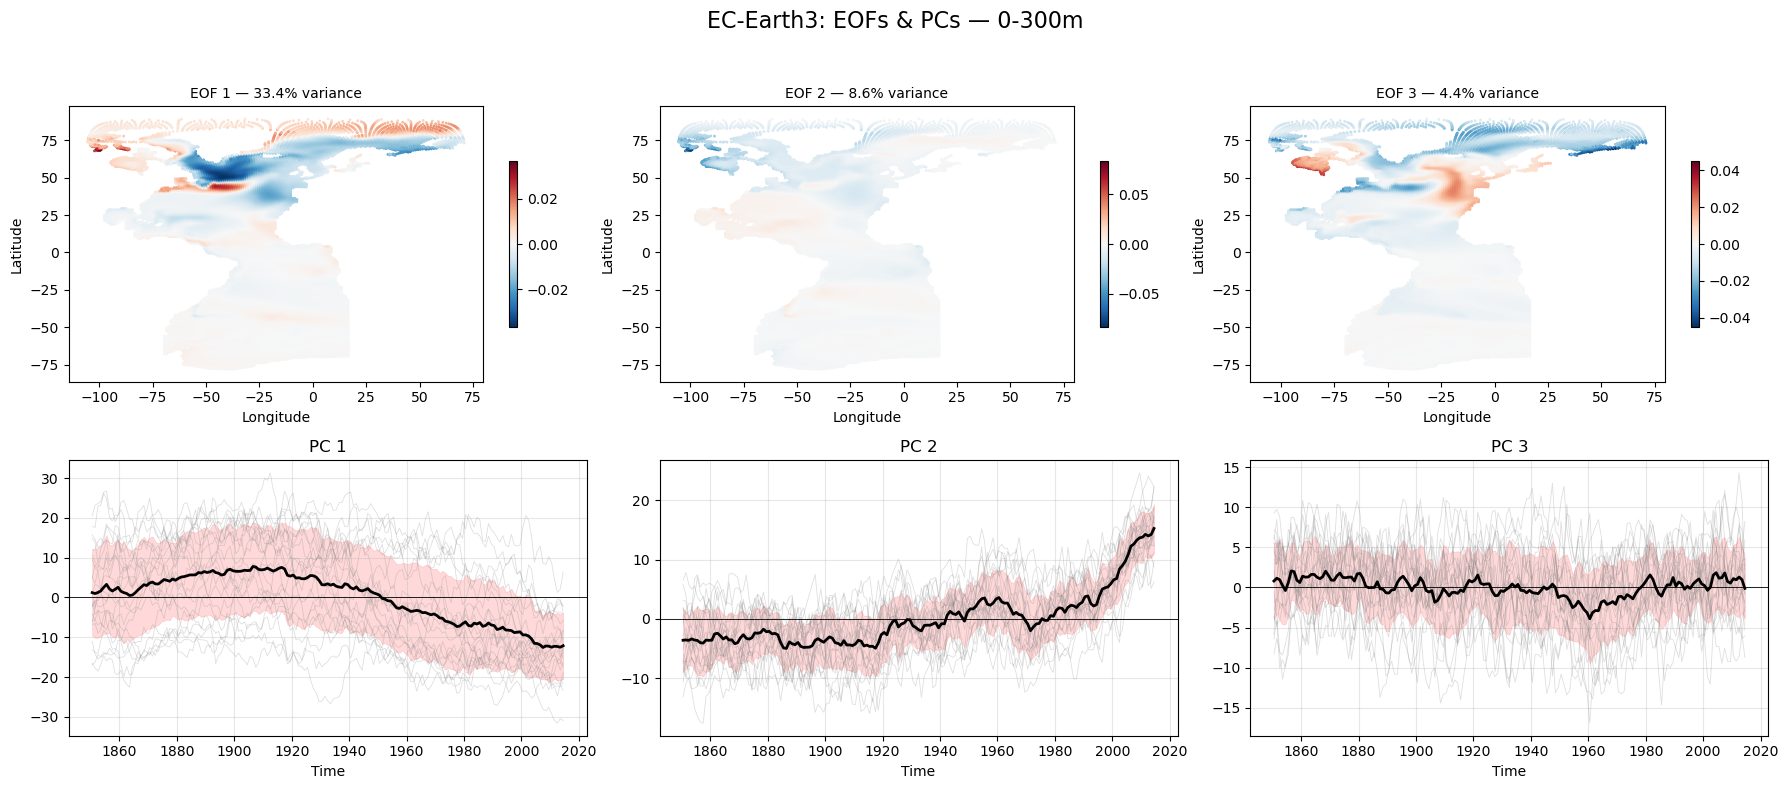

💾 Saved: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined_depthmeans/figures_native//EC-Earth3_EOF_PC_first3_0-300m.png


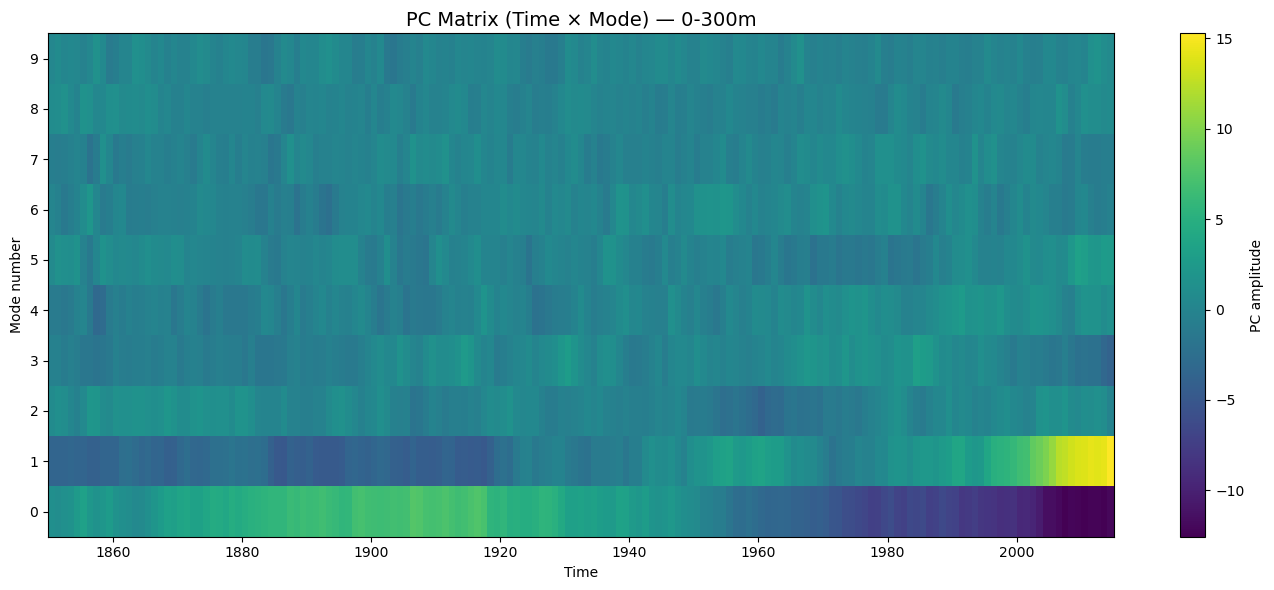

💾 Saved: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined_depthmeans/figures_native//EC-Earth3_PC_matrix_0-300m.png

📘 Plotting EOF + PC for depth range 0-1000m


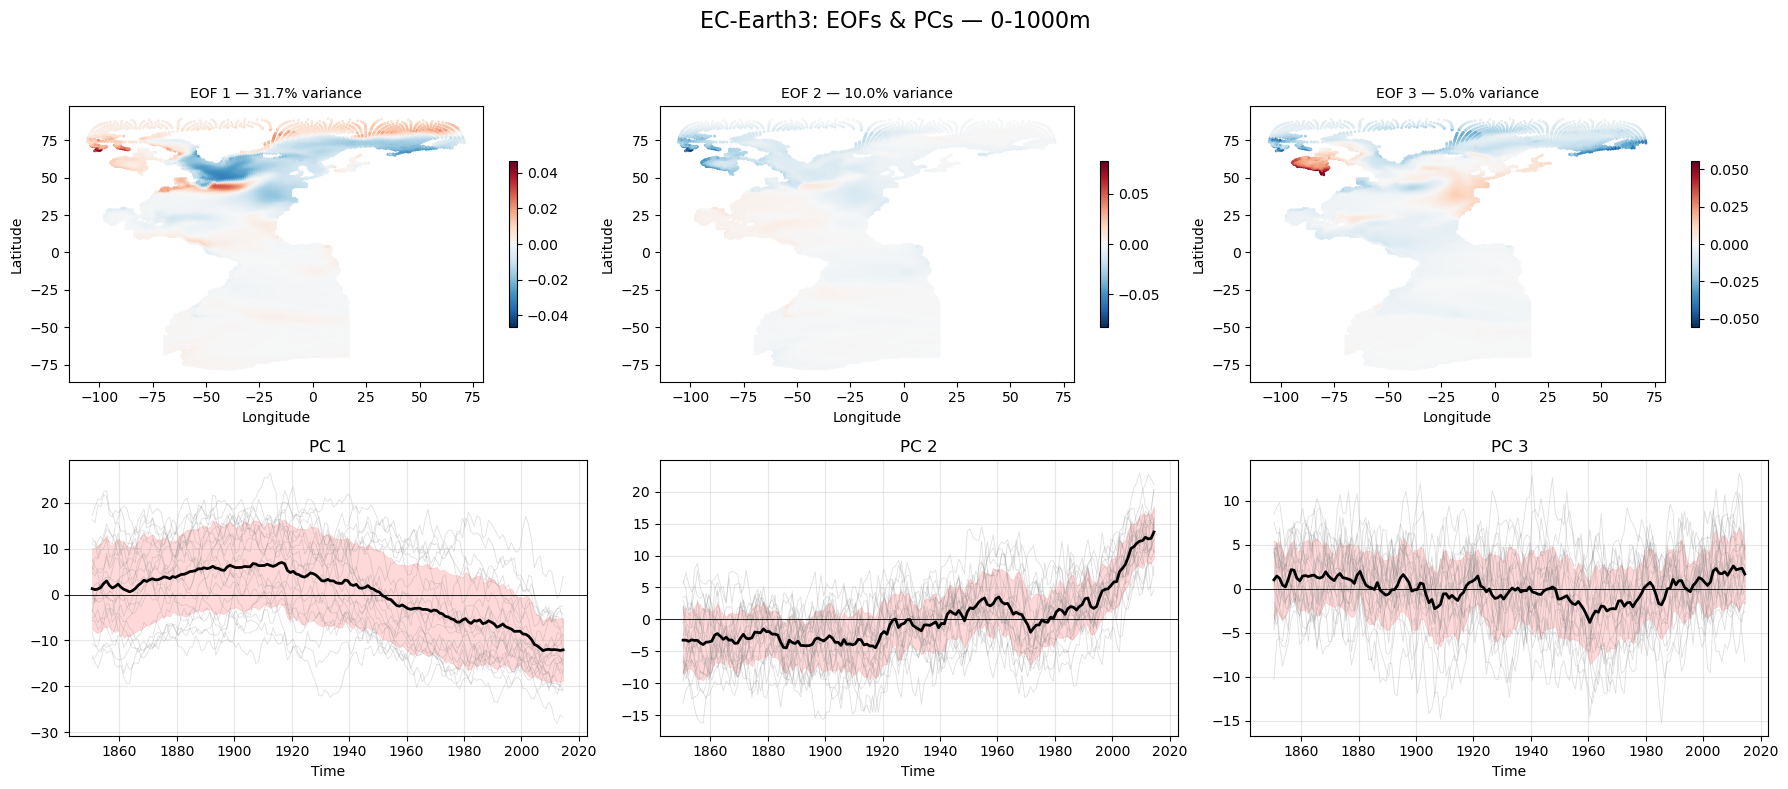

💾 Saved: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined_depthmeans/figures_native//EC-Earth3_EOF_PC_first3_0-1000m.png


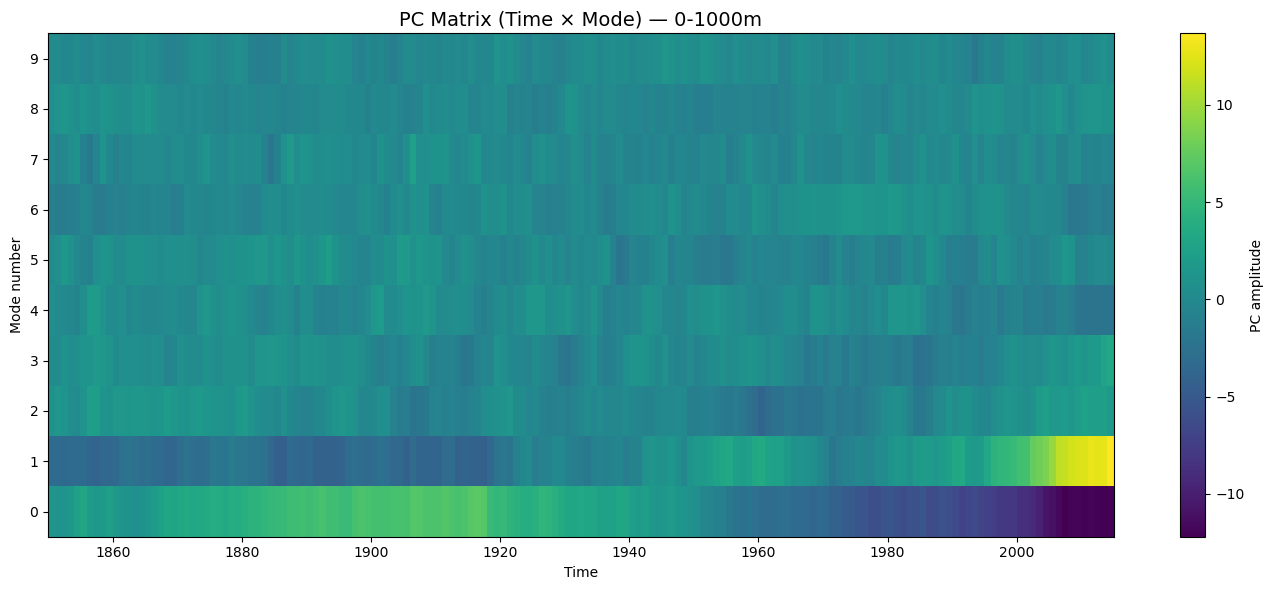

💾 Saved: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined_depthmeans/figures_native//EC-Earth3_PC_matrix_0-1000m.png

📘 Plotting EOF + PC for depth range 1000-5000m


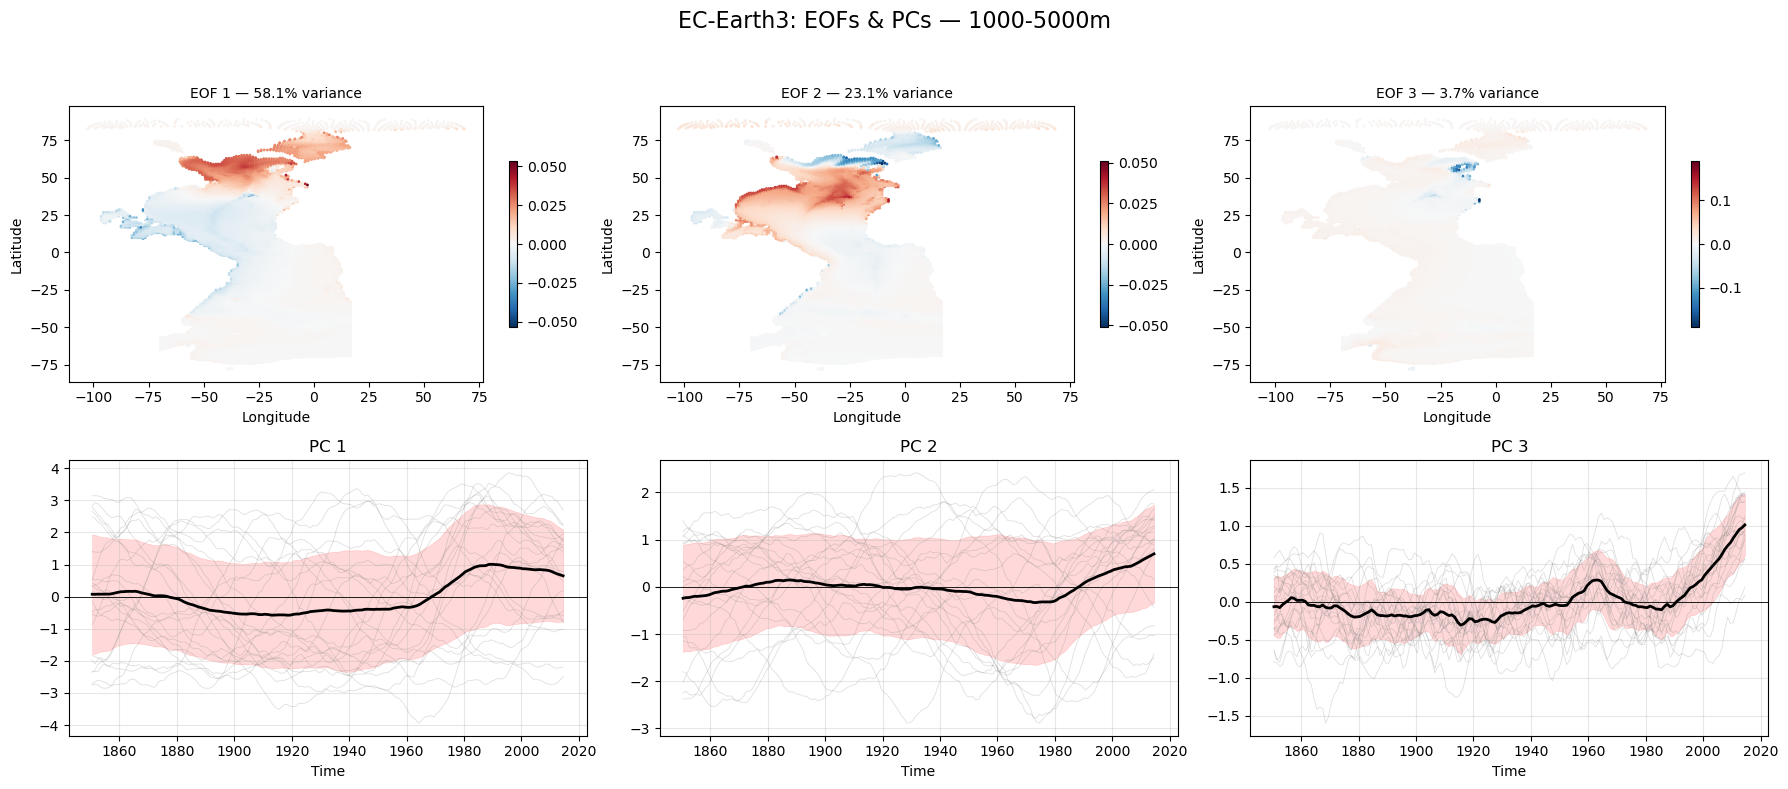

💾 Saved: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined_depthmeans/figures_native//EC-Earth3_EOF_PC_first3_1000-5000m.png


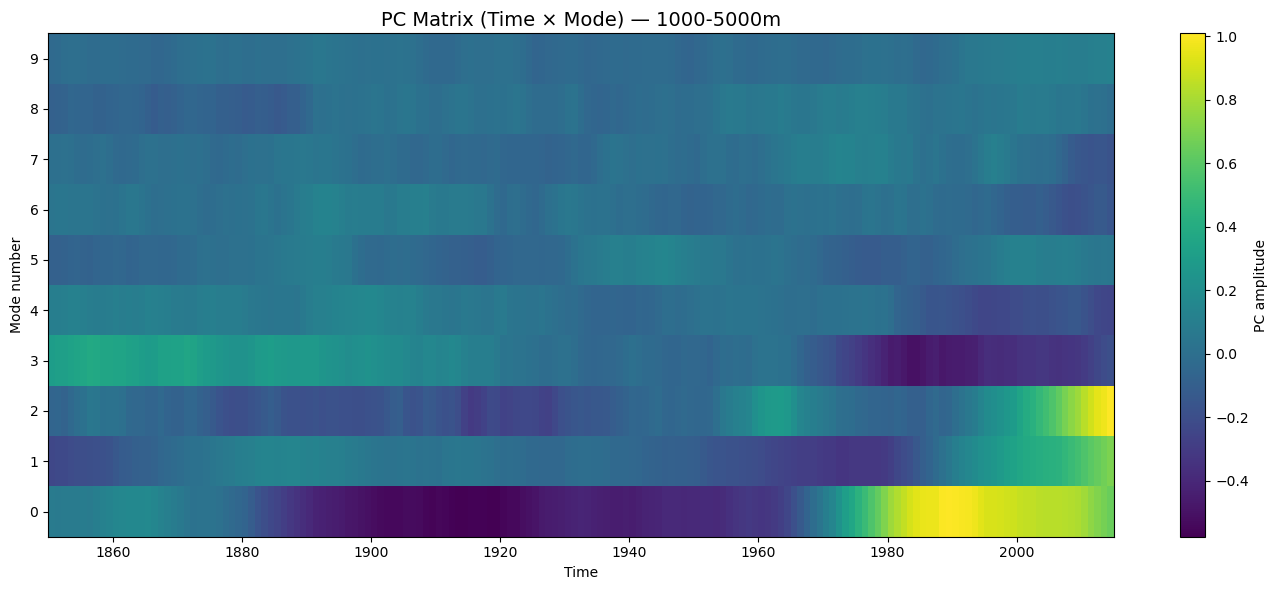

💾 Saved: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined_depthmeans/figures_native//EC-Earth3_PC_matrix_1000-5000m.png


In [2]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ============================================
# SETTINGS
# ============================================
MODEL = "EC-Earth3"
VAR   = "so"

EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/figures_native/"
os.makedirs(OUT_DIR, exist_ok=True)

DEPTH_LABELS = [
    "0-300m",
    "0-1000m",
    "1000-5000m"
]

NMODES = 3   # plot EOF/PC modes 1–3


# ============================================================
#  Helper: symmetric color range
# ============================================================
def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax


# ============================================================
# Helper: Native-grid scatter-method EOF plotting
# ============================================================
def plot_eof_native(ax, lat, lon, eof_field, title):
    lon2 = ((lon + 180) % 360) - 180   # wrap to [-180,180]

    vmin, vmax = symmetric_clim(eof_field)

    sc = ax.scatter(
        lon2.values, lat.values,
        c=eof_field.values,
        s=1.0,
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
    )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, shrink=0.6)


# ============================================================
# MAIN LOOP OVER DEPTH RANGES
# ============================================================
for dlabel in DEPTH_LABELS:

    print(f"\n📘 Plotting EOF + PC for depth range {dlabel}")

    # --- load file ---
    fpattern = f"{EOF_DIR}/EOF_combined_{VAR}_depthmean_{dlabel}.nc"
    files = glob.glob(fpattern)
    if not files:
        print(f"❌ File not found: {fpattern}")
        continue

    ds = xr.open_dataset(files[0])

    EOF = ds["EOF"]         # (mode, y, x)
    PC  = ds["PC"]          # (member, time, mode)
    VF  = ds["variance_fraction"].values
    lat = ds["lat"]
    lon = ds["lon"]
    time = ds["time"]

    # ============================================
    # FIX TIME AXIS (cftime → numpy datetime64)
    # ============================================
    if not np.issubdtype(time.dtype, np.datetime64):
        try:
            time = ds.indexes["time"].to_datetimeindex().values
        except:
            time = ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    else:
        time = time.values

    # ============================================
    # FIGURE 1: EOF1–3 + PC1–3
    # ============================================
    fig, axes = plt.subplots(2, NMODES, figsize=(18, 8))
    fig.suptitle(f"{MODEL}: EOFs & PCs — {dlabel}", fontsize=16)

    # ------------------------------
    # 1. EOF Spatial Maps
    # ------------------------------
    for m in range(NMODES):
        var_exp = VF[m] * 100.0
        title = f"EOF {m+1} — {var_exp:.1f}% variance"

        plot_eof_native(
            axes[0, m],
            lat, lon,
            EOF.isel(mode=m),
            title=title
        )

    # ------------------------------
    # 2. PC Timeseries
    # ------------------------------
    for m in range(NMODES):
        ax = axes[1, m]
        pcs_all  = PC.isel(mode=m)        # (member, time)
        pcs_mean = pcs_all.mean("member")
        pcs_std  = pcs_all.std("member")

        # all members (grey lines)
        for mem in range(pcs_all.sizes["member"]):
            ax.plot(
                time,
                pcs_all.isel(member=mem),
                color="gray",
                alpha=0.25,
                lw=0.6
            )

        # mean
        ax.plot(time, pcs_mean, color="black", lw=2)

        # ±std shading
        ax.fill_between(
            time,
            pcs_mean - pcs_std,
            pcs_mean + pcs_std,
            color="red",
            alpha=0.15,
            edgecolor="red",
            linewidth=0.5,
        )

        ax.axhline(0, color="black", lw=0.6)
        ax.grid(alpha=0.3)
        ax.set_title(f"PC {m+1}")
        ax.set_xlabel("Time")

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outfile = f"{OUT_DIR}/{MODEL}_EOF_PC_first3_{dlabel}.png"
    # fig.savefig(outfile, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile}")

    # ============================================
    # FIGURE 2: PC MATRIX (time × mode)
    # ============================================
    fig, ax = plt.subplots(figsize=(14, 6))

    # member-mean over members
    pc_matrix = PC.mean("member").transpose("mode", "time").values  # (mode,time)

    pcm = ax.pcolormesh(
        time,
        np.arange(pc_matrix.shape[0]),
        pc_matrix,
        cmap="viridis",
        shading="nearest"        # ← IMPORTANT FIX
    )

    ax.set_title(f"PC Matrix (Time × Mode) — {dlabel}", fontsize=14)
    ax.set_ylabel("Mode number")
    ax.set_xlabel("Time")
    ax.set_yticks(np.arange(pc_matrix.shape[0]))
    plt.colorbar(pcm, ax=ax, label="PC amplitude")

    fig.tight_layout()
    outfile2 = f"{OUT_DIR}/{MODEL}_PC_matrix_{dlabel}.png"
    # fig.savefig(outfile2, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile2}")



📘 Plotting EOF + PC for depth range 0-300m


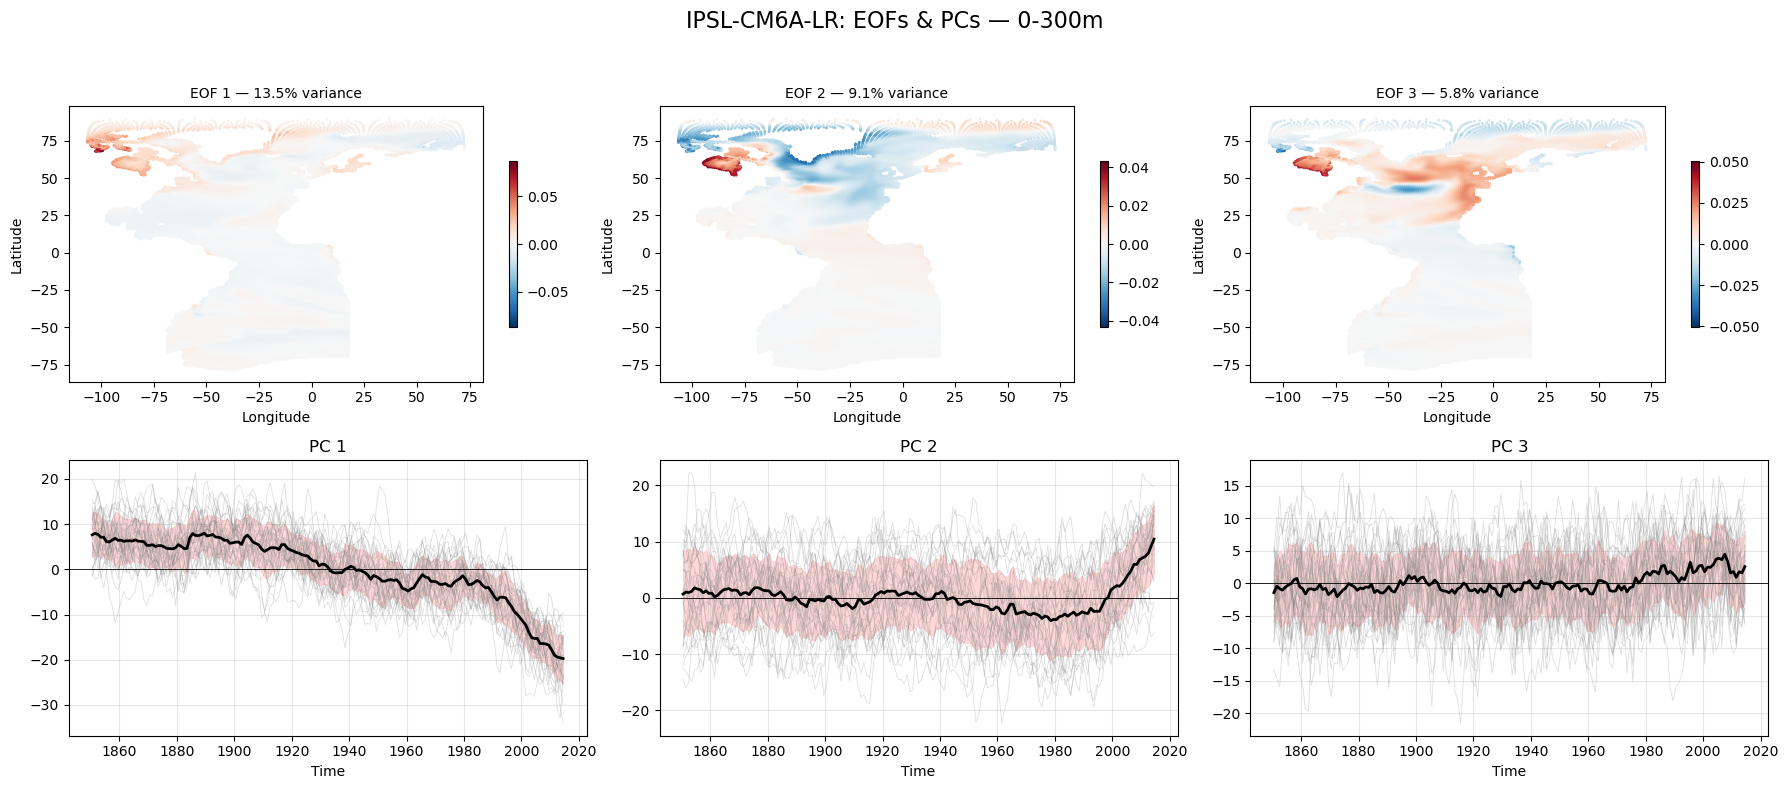

💾 Saved: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined_depthmeans/figures_native//IPSL-CM6A-LR_EOF_PC_first3_0-300m.png


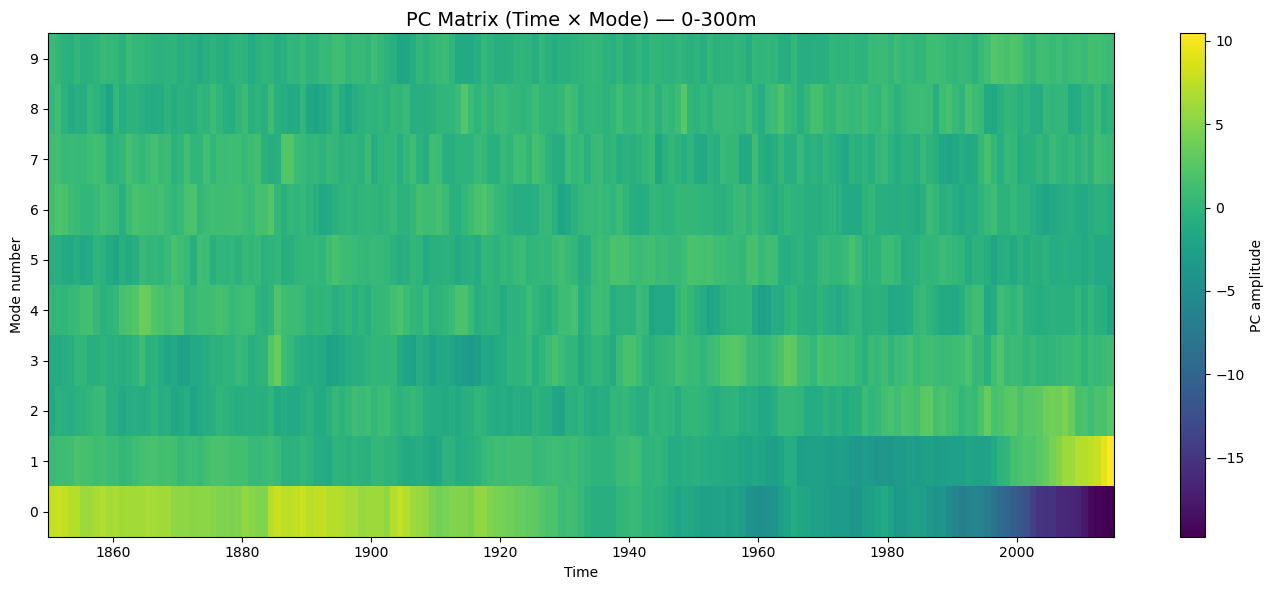

💾 Saved: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined_depthmeans/figures_native//IPSL-CM6A-LR_PC_matrix_0-300m.png

📘 Plotting EOF + PC for depth range 0-1000m


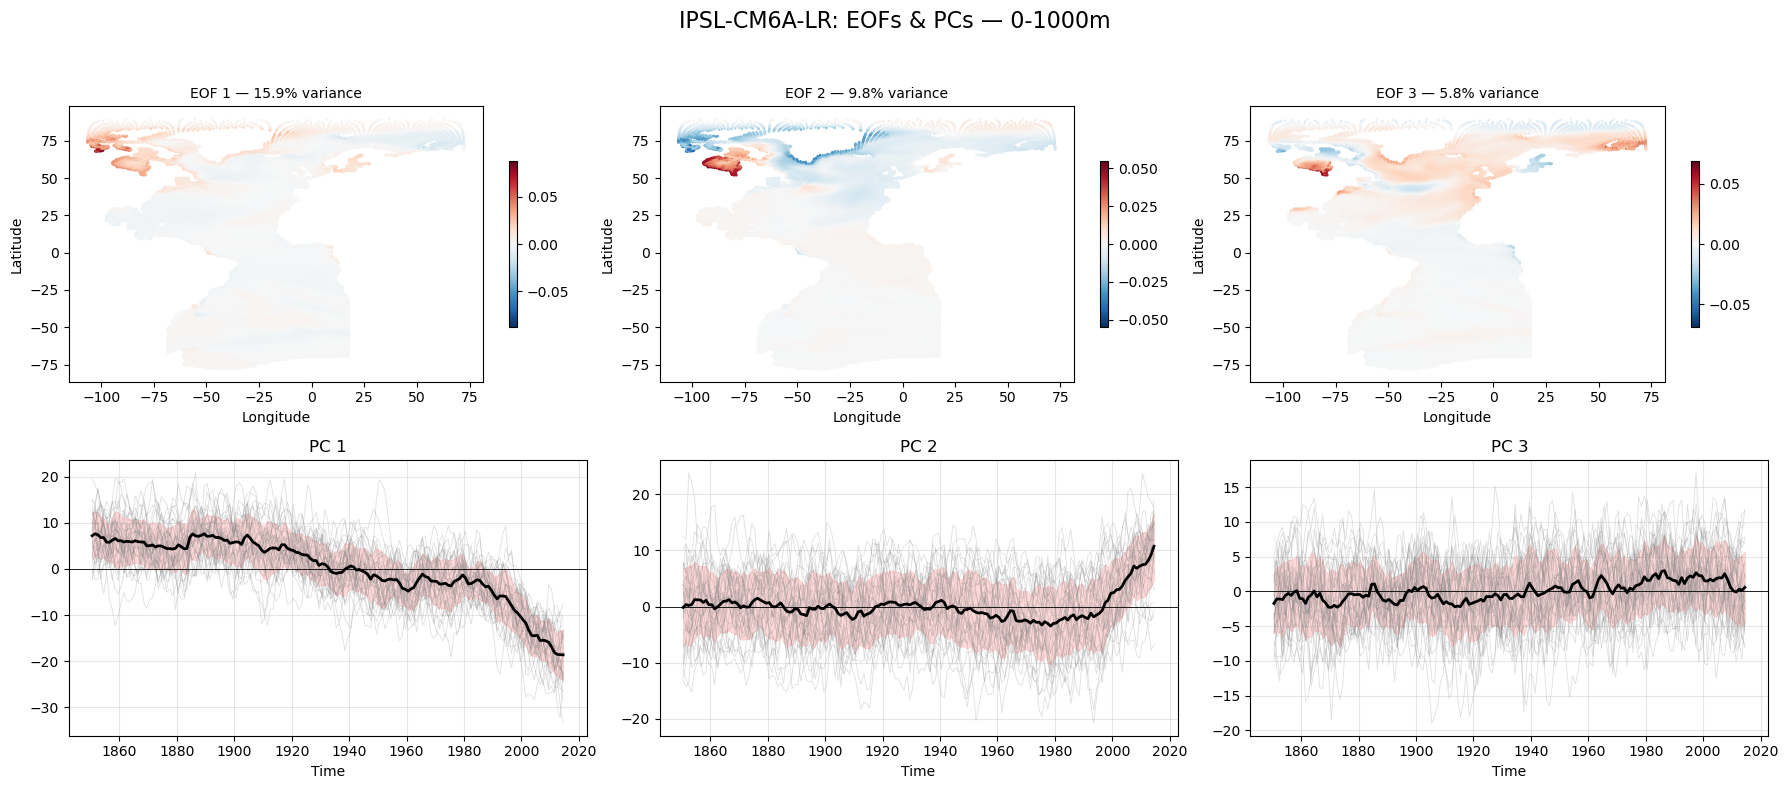

💾 Saved: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined_depthmeans/figures_native//IPSL-CM6A-LR_EOF_PC_first3_0-1000m.png


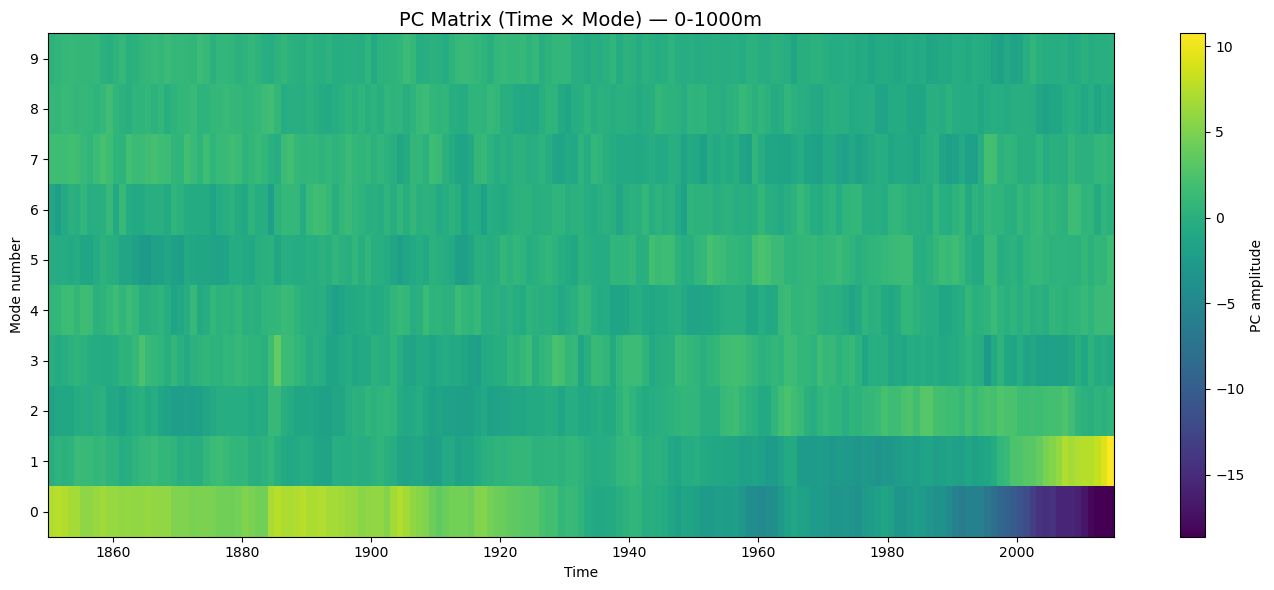

💾 Saved: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined_depthmeans/figures_native//IPSL-CM6A-LR_PC_matrix_0-1000m.png

📘 Plotting EOF + PC for depth range 1000-5000m


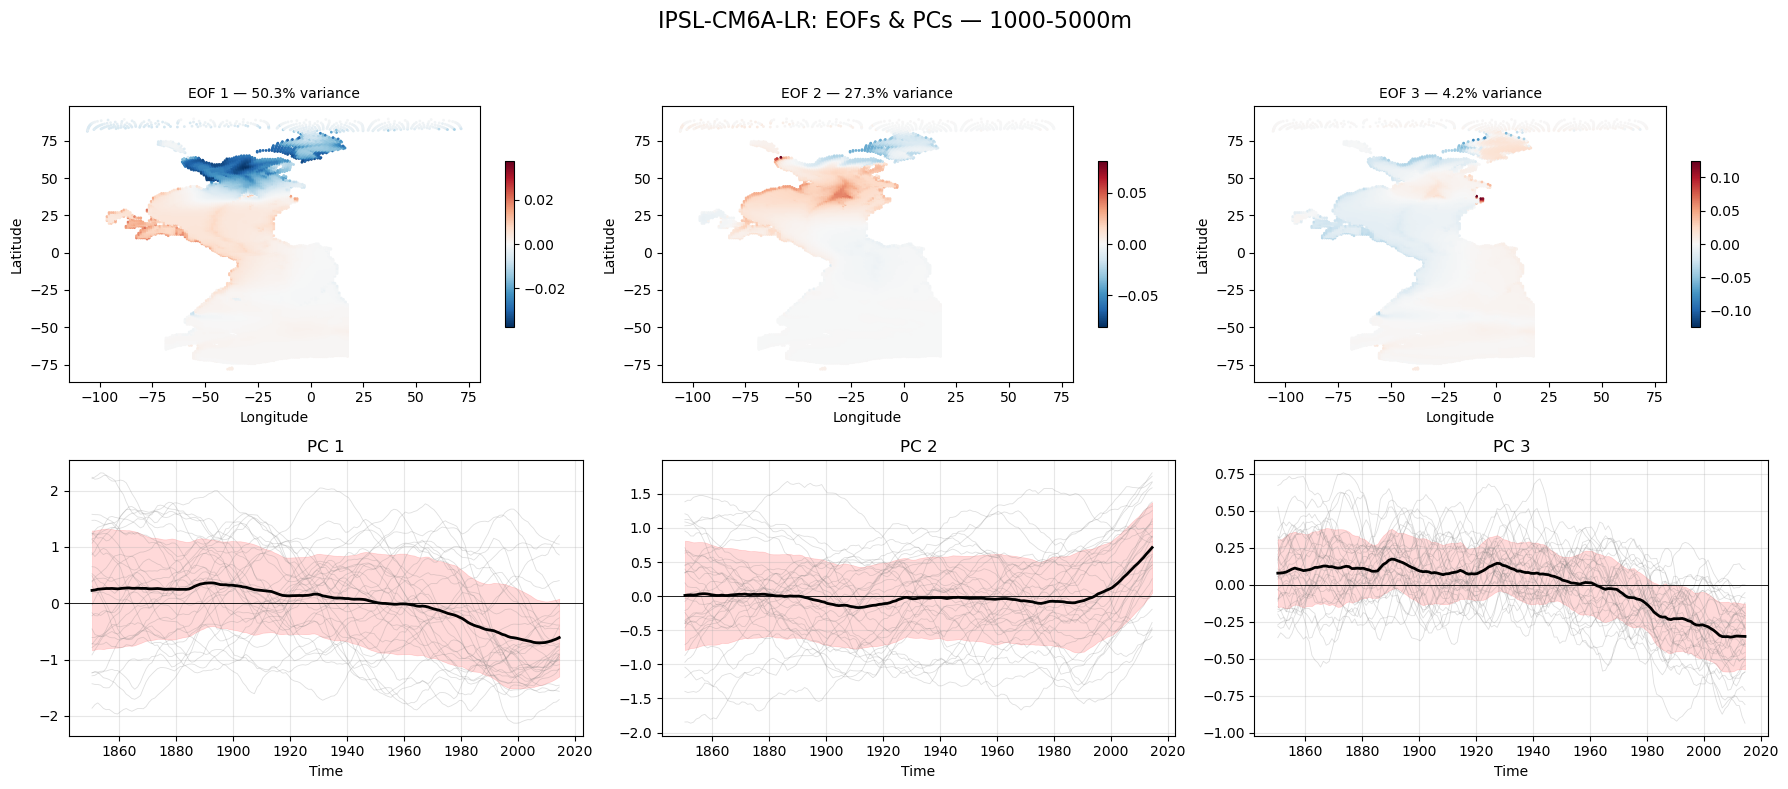

💾 Saved: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined_depthmeans/figures_native//IPSL-CM6A-LR_EOF_PC_first3_1000-5000m.png


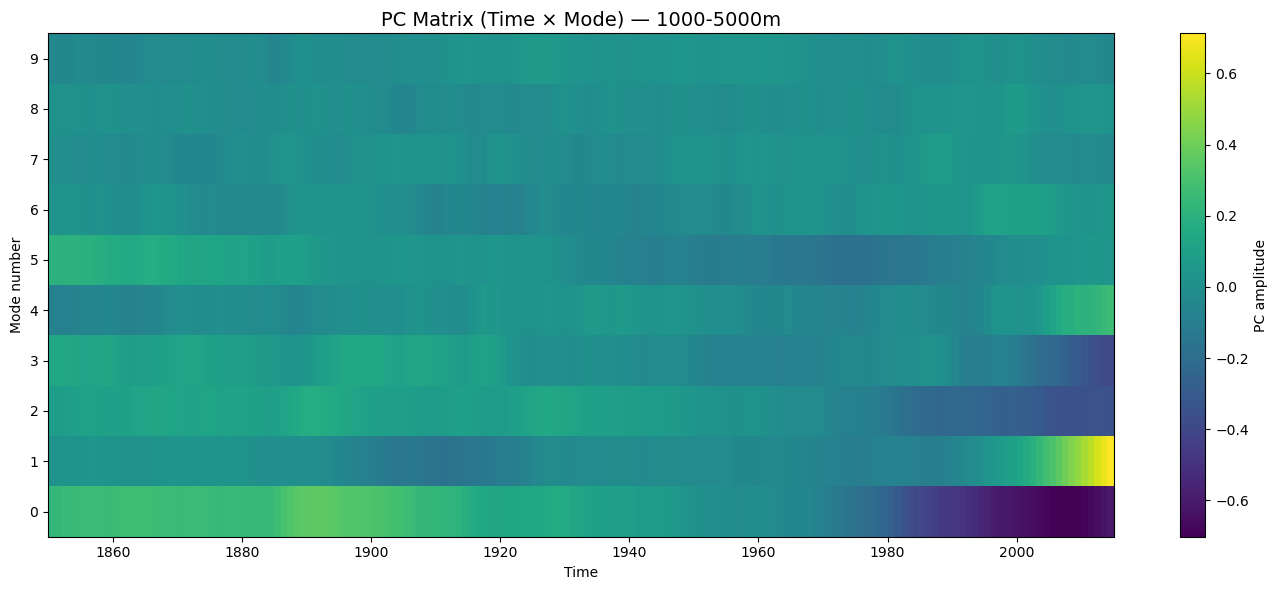

💾 Saved: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined_depthmeans/figures_native//IPSL-CM6A-LR_PC_matrix_1000-5000m.png


In [8]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ============================================
# SETTINGS
# ============================================
MODEL = "IPSL-CM6A-LR"
VAR   = "so"

EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/figures_native/"
os.makedirs(OUT_DIR, exist_ok=True)

DEPTH_LABELS = [
    "0-300m",
    "0-1000m",
    "1000-5000m"
]

NMODES = 3   # plot EOF/PC modes 1–3


# ============================================================
#  Helper: symmetric color range
# ============================================================
def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax


# ============================================================
# Helper: Native-grid scatter-method EOF plotting
# ============================================================
def plot_eof_native(ax, lat, lon, eof_field, title):
    lon2 = ((lon + 180) % 360) - 180   # wrap to [-180,180]

    vmin, vmax = symmetric_clim(eof_field)

    sc = ax.scatter(
        lon2.values, lat.values,
        c=eof_field.values,
        s=1.0,
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
    )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, shrink=0.6)


# ============================================================
# MAIN LOOP OVER DEPTH RANGES
# ============================================================
for dlabel in DEPTH_LABELS:

    print(f"\n📘 Plotting EOF + PC for depth range {dlabel}")

    # --- load file ---
    fpattern = f"{EOF_DIR}/EOF_combined_{VAR}_depthmean_{dlabel}.nc"
    files = glob.glob(fpattern)
    if not files:
        print(f"❌ File not found: {fpattern}")
        continue

    ds = xr.open_dataset(files[0])

    EOF = ds["EOF"]         # (mode, y, x)
    PC  = ds["PC"]          # (member, time, mode)
    VF  = ds["variance_fraction"].values
    lat = ds["lat"]
    lon = ds["lon"]
    time = ds["time"]

    # ============================================
    # FIX TIME AXIS (cftime → numpy datetime64)
    # ============================================
    if not np.issubdtype(time.dtype, np.datetime64):
        try:
            time = ds.indexes["time"].to_datetimeindex().values
        except:
            time = ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    else:
        time = time.values

    # ============================================
    # FIGURE 1: EOF1–3 + PC1–3
    # ============================================
    fig, axes = plt.subplots(2, NMODES, figsize=(18, 8))
    fig.suptitle(f"{MODEL}: EOFs & PCs — {dlabel}", fontsize=16)

    # ------------------------------
    # 1. EOF Spatial Maps
    # ------------------------------
    for m in range(NMODES):
        var_exp = VF[m] * 100.0
        title = f"EOF {m+1} — {var_exp:.1f}% variance"

        plot_eof_native(
            axes[0, m],
            lat, lon,
            EOF.isel(mode=m),
            title=title
        )

    # ------------------------------
    # 2. PC Timeseries
    # ------------------------------
    for m in range(NMODES):
        ax = axes[1, m]
        pcs_all  = PC.isel(mode=m)        # (member, time)
        pcs_mean = pcs_all.mean("member")
        pcs_std  = pcs_all.std("member")

        # all members (grey lines)
        for mem in range(pcs_all.sizes["member"]):
            ax.plot(
                time,
                pcs_all.isel(member=mem),
                color="gray",
                alpha=0.25,
                lw=0.6
            )

        # mean
        ax.plot(time, pcs_mean, color="black", lw=2)

        # ±std shading
        ax.fill_between(
            time,
            pcs_mean - pcs_std,
            pcs_mean + pcs_std,
            color="red",
            alpha=0.15,
            edgecolor="red",
            linewidth=0.5,
        )

        ax.axhline(0, color="black", lw=0.6)
        ax.grid(alpha=0.3)
        ax.set_title(f"PC {m+1}")
        ax.set_xlabel("Time")

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outfile = f"{OUT_DIR}/{MODEL}_EOF_PC_first3_{dlabel}.png"
    # fig.savefig(outfile, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile}")

    # ============================================
    # FIGURE 2: PC MATRIX (time × mode)
    # ============================================
    fig, ax = plt.subplots(figsize=(14, 6))

    # member-mean over members
    pc_matrix = PC.mean("member").transpose("mode", "time").values  # (mode,time)

    pcm = ax.pcolormesh(
        time,
        np.arange(pc_matrix.shape[0]),
        pc_matrix,
        cmap="viridis",
        shading="nearest"        # ← IMPORTANT FIX
    )

    ax.set_title(f"PC Matrix (Time × Mode) — {dlabel}", fontsize=14)
    ax.set_ylabel("Mode number")
    ax.set_xlabel("Time")
    ax.set_yticks(np.arange(pc_matrix.shape[0]))
    plt.colorbar(pcm, ax=ax, label="PC amplitude")

    fig.tight_layout()
    outfile2 = f"{OUT_DIR}/{MODEL}_PC_matrix_{dlabel}.png"
    # fig.savefig(outfile2, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile2}")



📘 Plotting EOF + PC for depth range 0-300m


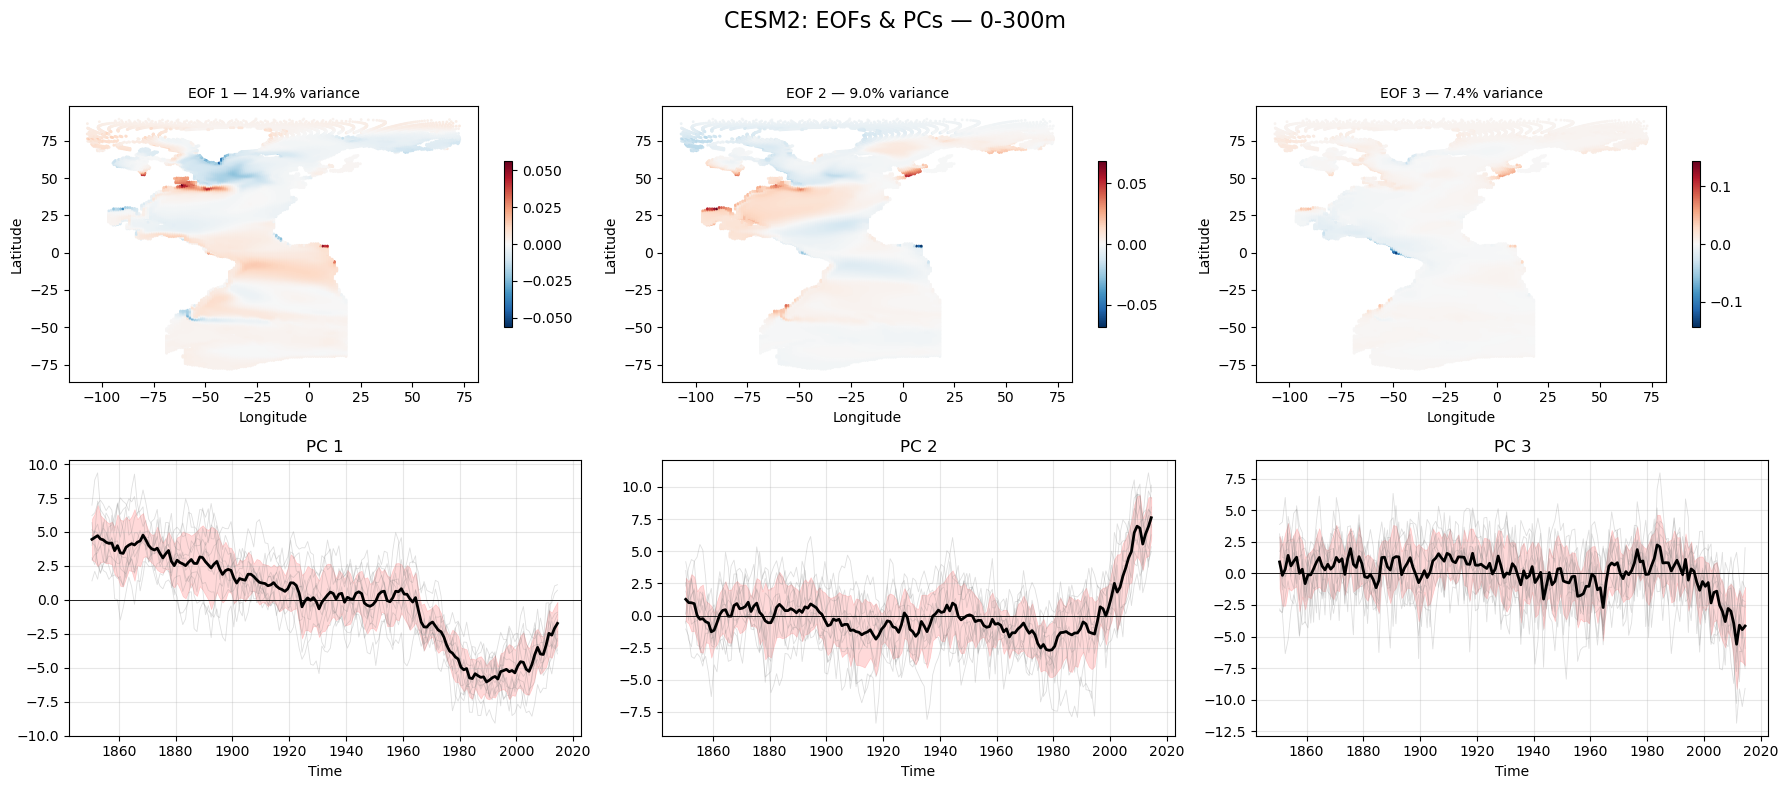

💾 Saved: /data/projects/nckf/frekle/EOF_results/CESM2/combined_depthmeans/figures_native//CESM2_EOF_PC_first3_0-300m.png


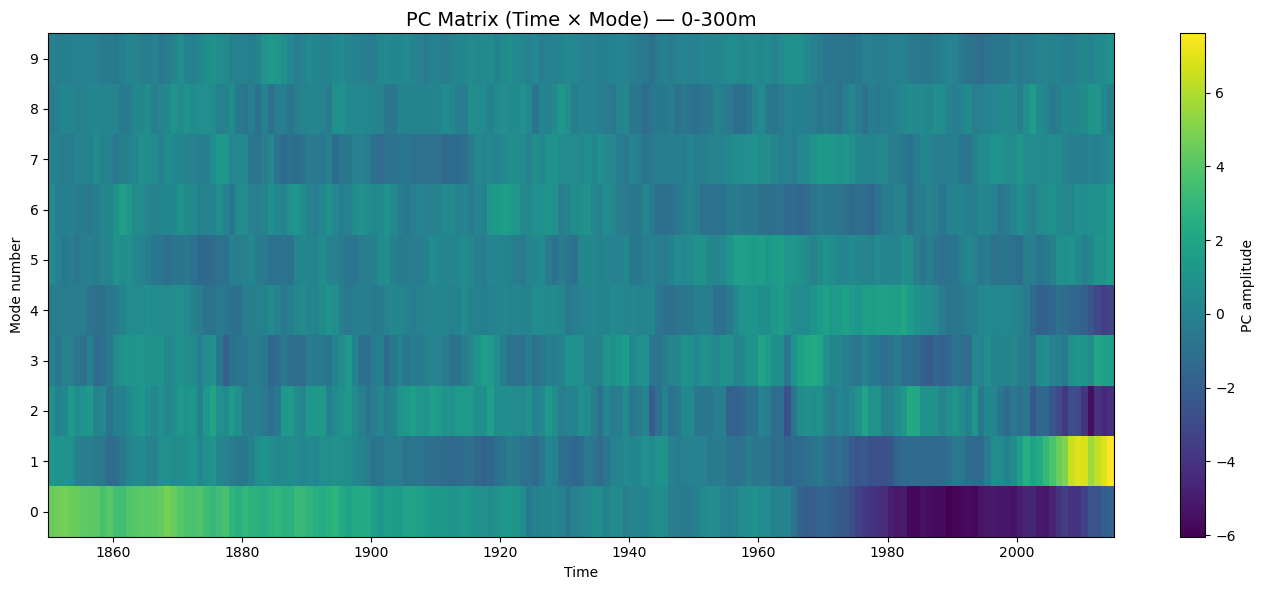

💾 Saved: /data/projects/nckf/frekle/EOF_results/CESM2/combined_depthmeans/figures_native//CESM2_PC_matrix_0-300m.png

📘 Plotting EOF + PC for depth range 0-1000m


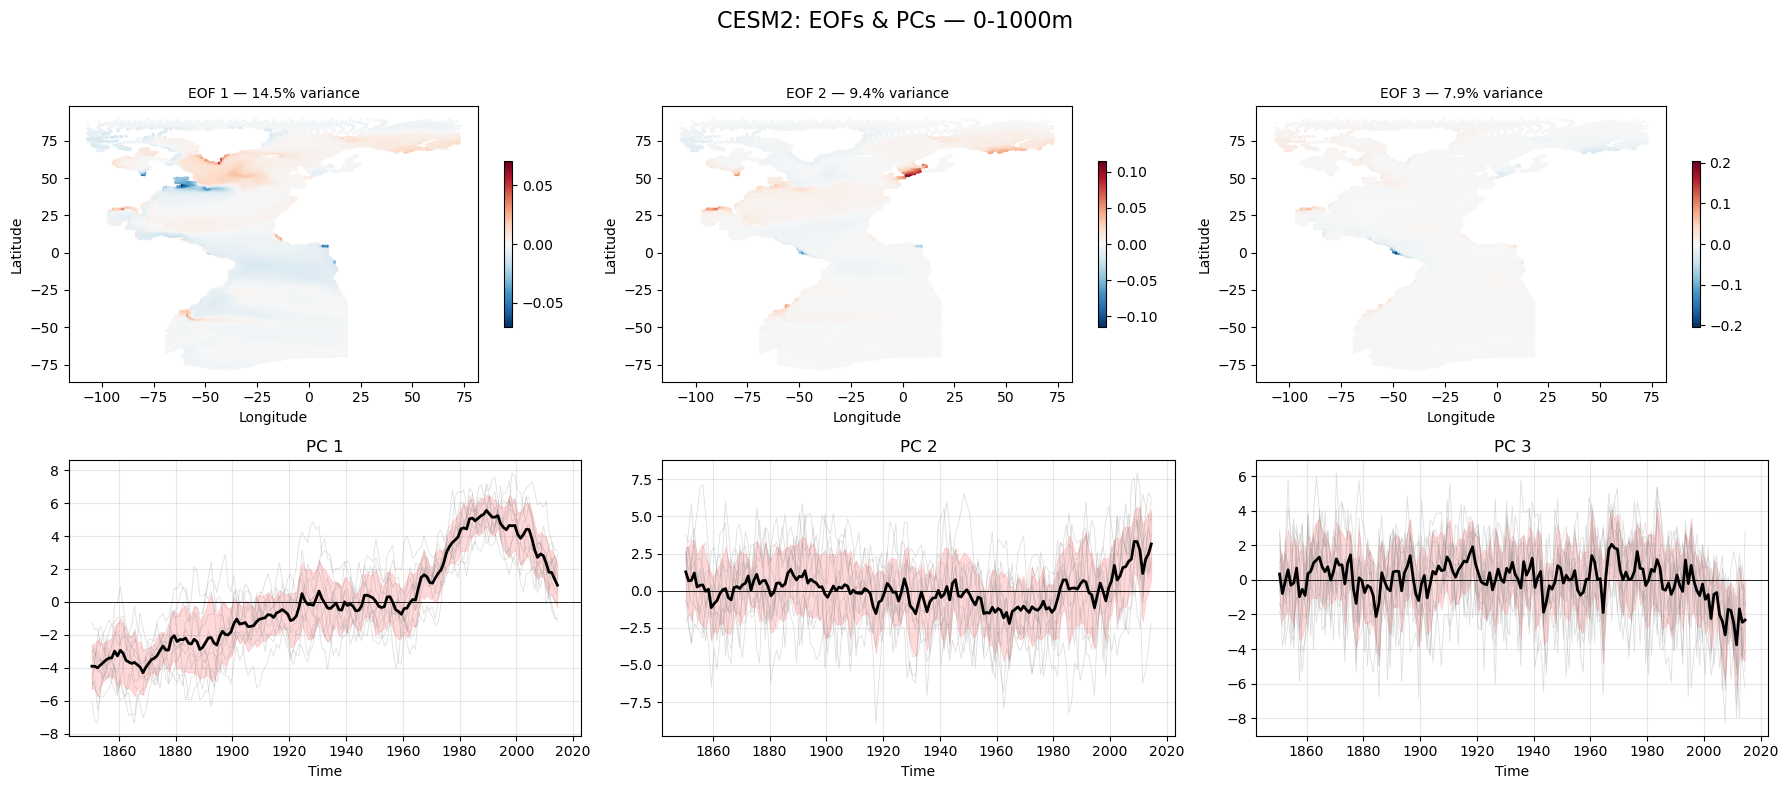

💾 Saved: /data/projects/nckf/frekle/EOF_results/CESM2/combined_depthmeans/figures_native//CESM2_EOF_PC_first3_0-1000m.png


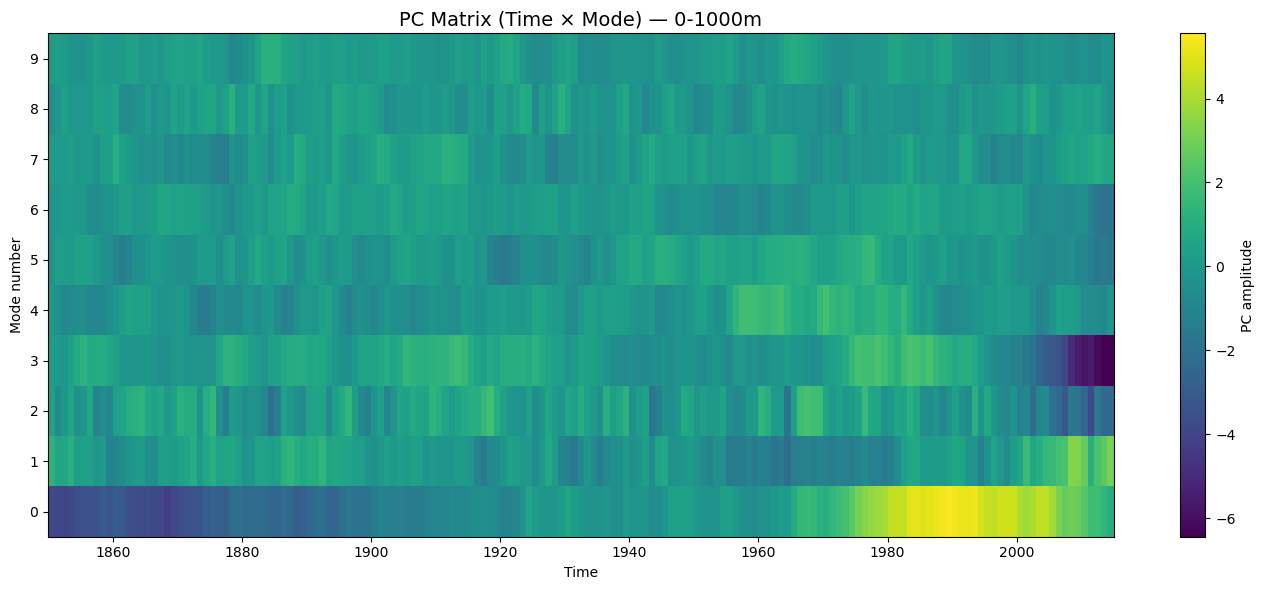

💾 Saved: /data/projects/nckf/frekle/EOF_results/CESM2/combined_depthmeans/figures_native//CESM2_PC_matrix_0-1000m.png

📘 Plotting EOF + PC for depth range 1000-5000m


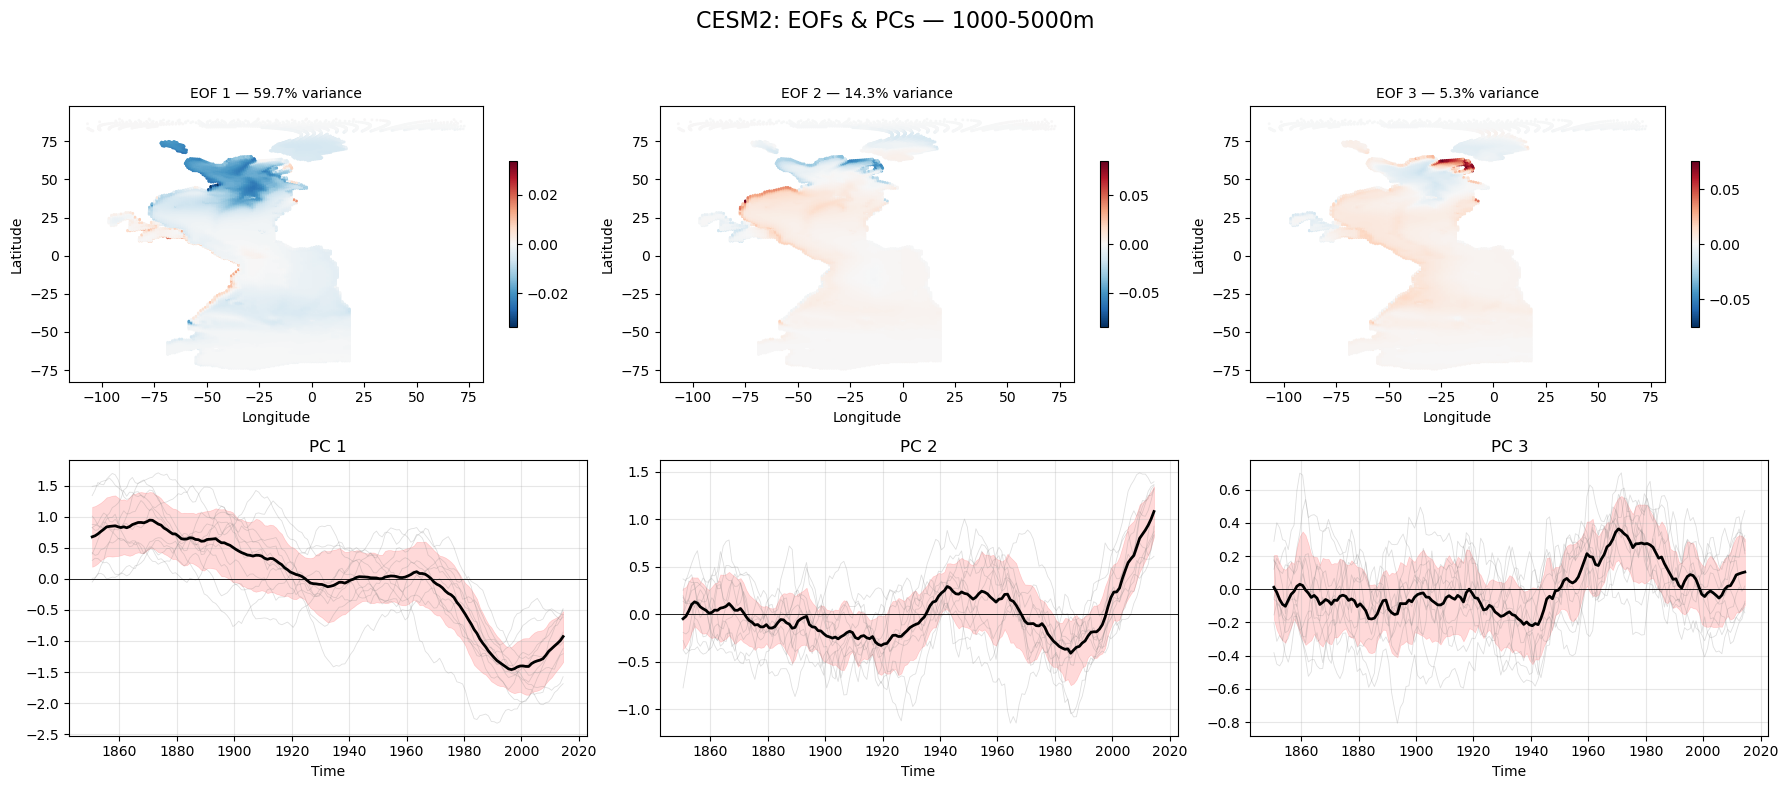

💾 Saved: /data/projects/nckf/frekle/EOF_results/CESM2/combined_depthmeans/figures_native//CESM2_EOF_PC_first3_1000-5000m.png


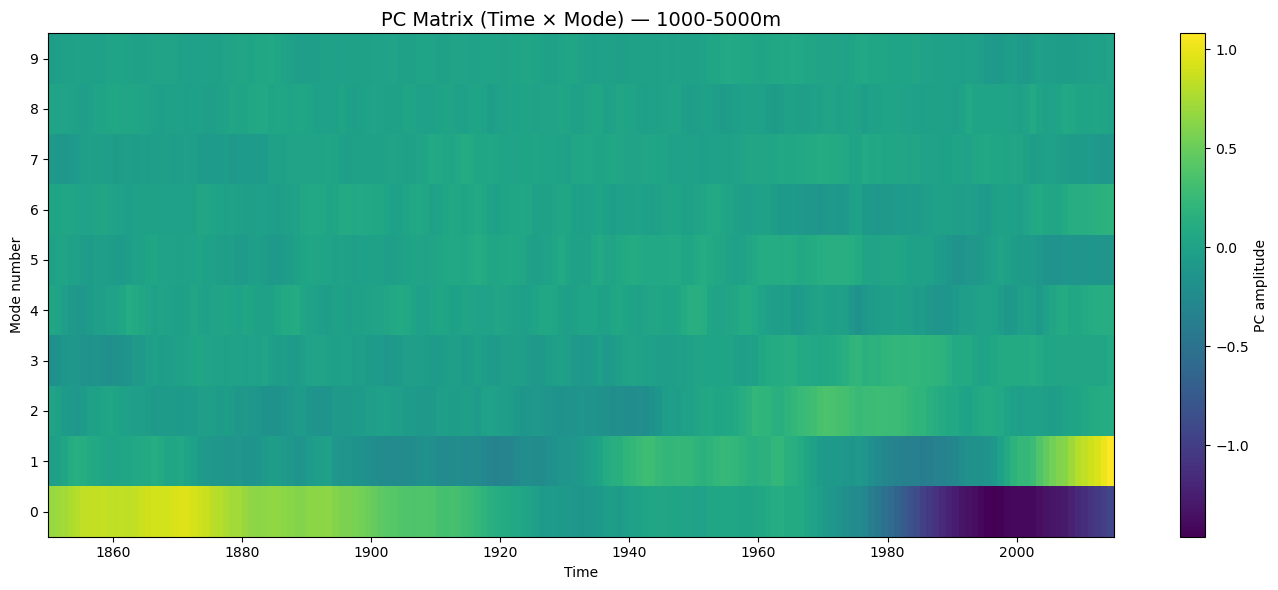

💾 Saved: /data/projects/nckf/frekle/EOF_results/CESM2/combined_depthmeans/figures_native//CESM2_PC_matrix_1000-5000m.png


In [3]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ============================================
# SETTINGS
# ============================================
MODEL = "CESM2"
VAR   = "so"

EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/figures_native/"
os.makedirs(OUT_DIR, exist_ok=True)

DEPTH_LABELS = [
    "0-300m",
    "0-1000m",
    "1000-5000m"
]

NMODES = 3   # plot EOF/PC modes 1–3


# ============================================================
#  Helper: symmetric color range
# ============================================================
def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax


# ============================================================
# Helper: Native-grid scatter-method EOF plotting
# ============================================================
def plot_eof_native(ax, lat, lon, eof_field, title):
    lon2 = ((lon + 180) % 360) - 180   # wrap to [-180,180]

    vmin, vmax = symmetric_clim(eof_field)

    sc = ax.scatter(
        lon2.values, lat.values,
        c=eof_field.values,
        s=1.0,
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
    )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, shrink=0.6)


# ============================================================
# MAIN LOOP OVER DEPTH RANGES
# ============================================================
for dlabel in DEPTH_LABELS:

    print(f"\n📘 Plotting EOF + PC for depth range {dlabel}")

    # --- load file ---
    fpattern = f"{EOF_DIR}/EOF_combined_{VAR}_depthmean_{dlabel}.nc"
    files = glob.glob(fpattern)
    if not files:
        print(f"❌ File not found: {fpattern}")
        continue

    ds = xr.open_dataset(files[0])

    EOF = ds["EOF"]         # (mode, y, x)
    PC  = ds["PC"]          # (member, time, mode)
    VF  = ds["variance_fraction"].values
    lat = ds["lat"]
    lon = ds["lon"]
    time = ds["time"]

    # ============================================
    # FIX TIME AXIS (cftime → numpy datetime64)
    # ============================================
    if not np.issubdtype(time.dtype, np.datetime64):
        try:
            time = ds.indexes["time"].to_datetimeindex().values
        except:
            time = ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    else:
        time = time.values

    # ============================================
    # FIGURE 1: EOF1–3 + PC1–3
    # ============================================
    fig, axes = plt.subplots(2, NMODES, figsize=(18, 8))
    fig.suptitle(f"{MODEL}: EOFs & PCs — {dlabel}", fontsize=16)

    # ------------------------------
    # 1. EOF Spatial Maps
    # ------------------------------
    for m in range(NMODES):
        var_exp = VF[m] * 100.0
        title = f"EOF {m+1} — {var_exp:.1f}% variance"

        plot_eof_native(
            axes[0, m],
            lat, lon,
            EOF.isel(mode=m),
            title=title
        )

    # ------------------------------
    # 2. PC Timeseries
    # ------------------------------
    for m in range(NMODES):
        ax = axes[1, m]
        pcs_all  = PC.isel(mode=m)        # (member, time)
        pcs_mean = pcs_all.mean("member")
        pcs_std  = pcs_all.std("member")

        # all members (grey lines)
        for mem in range(pcs_all.sizes["member"]):
            ax.plot(
                time,
                pcs_all.isel(member=mem),
                color="gray",
                alpha=0.25,
                lw=0.6
            )

        # mean
        ax.plot(time, pcs_mean, color="black", lw=2)

        # ±std shading
        ax.fill_between(
            time,
            pcs_mean - pcs_std,
            pcs_mean + pcs_std,
            color="red",
            alpha=0.15,
            edgecolor="red",
            linewidth=0.5,
        )

        ax.axhline(0, color="black", lw=0.6)
        ax.grid(alpha=0.3)
        ax.set_title(f"PC {m+1}")
        ax.set_xlabel("Time")

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outfile = f"{OUT_DIR}/{MODEL}_EOF_PC_first3_{dlabel}.png"
    # fig.savefig(outfile, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile}")

    # ============================================
    # FIGURE 2: PC MATRIX (time × mode)
    # ============================================
    fig, ax = plt.subplots(figsize=(14, 6))

    # member-mean over members
    pc_matrix = PC.mean("member").transpose("mode", "time").values  # (mode,time)

    pcm = ax.pcolormesh(
        time,
        np.arange(pc_matrix.shape[0]),
        pc_matrix,
        cmap="viridis",
        shading="nearest"        # ← IMPORTANT FIX
    )

    ax.set_title(f"PC Matrix (Time × Mode) — {dlabel}", fontsize=14)
    ax.set_ylabel("Mode number")
    ax.set_xlabel("Time")
    ax.set_yticks(np.arange(pc_matrix.shape[0]))
    plt.colorbar(pcm, ax=ax, label="PC amplitude")

    fig.tight_layout()
    outfile2 = f"{OUT_DIR}/{MODEL}_PC_matrix_{dlabel}.png"
    # fig.savefig(outfile2, dpi=150)
    plt.show()
    print(f"💾 Saved: {outfile2}")
